# Etna Cause–Trigger Analysis

This notebook runs the Cause–Trigger algorithm on the Etna dataset using three causal-discovery backends:

1. **HMML** — baseline.
2. **PCMCI** — lagged causal-discovery sensitivity backend.
3. **PCMCI+** — lagged + contemporaneous causal-discovery backend.

## 1. Imports and paths 

In [1]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "etna"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_etna import *

ETNA_PATH = DATA_DIR / "etna_final.csv"
EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

In [2]:
X_full = load_model_frame(ETNA_PATH)

CASE_START = EVENT_TIME - pd.Timedelta(days=7)
CASE_END = EVENT_TIME + pd.Timedelta(days=3)

X = X_full.loc[CASE_START:CASE_END].copy()

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,240,9,2008-05-05 07:00:00+00:00,2008-05-15 06:00:00+00:00,h,effect_seismic_scaled,-0.647213,-0.463833,0.156921,2.016159,0.8438,2.32182,240


## 2. Automatic parameter selection, Main configuration and split check

Before any causal discovery, we check whether the split is scientifically sensible. The split is selected automatically from the effect variable. The known Wenchuan/teleseismic time is not used by the algorithm and is shown only as external temporal context.


In [ ]:
from parameter_extraction import find_parameters

selected_distribution, selected_lag = find_parameters(
    X=X,
    target_series=X[EFFECT],
    max_lags=12,
    criterion="aic",
    fallback_lag=1,
    fallback_distribution="gaussian",
)

pd.DataFrame([{
    "effect": EFFECT,
    "selected_lag": int(selected_lag),
    "selected_distribution": selected_distribution,
    "lag_method": "VAR-AIC",
    "max_lags": 6,
}])

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags
0,effect_seismic_scaled,2,gaussian,VAR-AIC,6


In [ ]:
workflow = EtnaWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=int(selected_lag),
    max_lags=12,
    min_I1_length=48,
    min_I2_length=48,
    distribution=selected_distribution,
    parameter_source="automatic",
)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,...,split_search_end,split_lag_buffer,split_score_start_index,split_score_end_index,split_score_start_time,split_score_end_time,split_score_I2_length,signed_mean_I1,signed_mean_I2,signed_mean_difference
0,effect_seismic_scaled,191,2008-05-13 06:00:00+00:00,191,49,0.064545,0.516998,0.452453,2008-05-12 06:28:00+00:00,0 days 23:32:00,...,None,2,191,240,2008-05-13 06:00:00+00:00,2008-05-15 06:00:00+00:00,49,0.064545,0.516998,0.452453


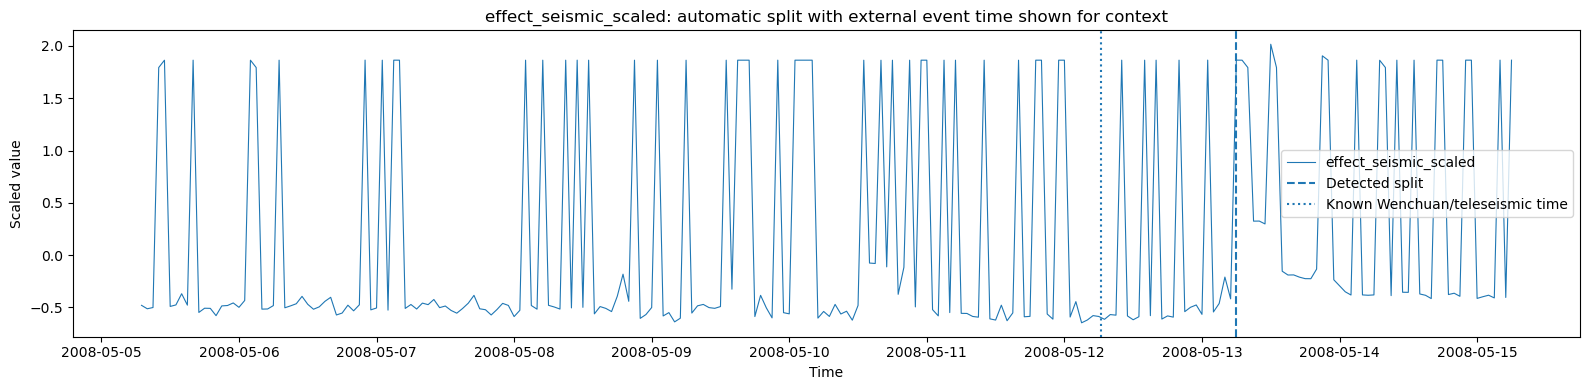

In [ ]:
main_split = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([main_split]))

plot_effect_with_split(
    X,
    EFFECT,
    main_split,
    event_time=workflow.event_time,
)

## 3. Main run

HMML is the baseline. PCMCI/PCMCI+ are extensions.

In [7]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


In [8]:
#display(compact_comparison(comparison))
display(comparison)

,run,effect,backend,parameter_source,configured_lags,configured_distribution,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,...,target_abs_mean_difference,B1,B2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,stop_reason
0,hmml_backend_beta,effect_seismic_scaled,hmml,automatic_hmml_lag2_gaussian_backend_beta,2,gaussian,backend,None,None,None,...,0.452453,[AirTemp_3_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0,No trigger candidate leaves a lagged B2 variab...
1,pcmci_ridge,effect_seismic_scaled,pcmci,automatic_pcmci_lag2_gaussian_ridge_refit,2,gaussian,refit,ridge,None,None,...,0.452453,[],[],False,[],[],[],[],0,No lagged non-target B2 variables available to...
2,pcmci_adaptive_lasso,effect_seismic_scaled,pcmci,automatic_pcmci_lag2_gaussian_adaptive_lasso_r...,2,gaussian,refit,adaptive_lasso,None,None,...,0.452453,[],[],False,[],[],[],[],0,No lagged non-target B2 variables available to...
3,pcmci_plus_ridge,effect_seismic_scaled,pcmci_plus,automatic_pcmci_plus_lag2_gaussian_ridge_refit,2,gaussian,refit,ridge,None,None,...,0.452453,[],[],False,[],[],[],[],1,No lagged non-target B2 variables available to...
4,pcmci_plus_adaptive_lasso,effect_seismic_scaled,pcmci_plus,automatic_pcmci_plus_lag2_gaussian_adaptive_la...,2,gaussian,refit,adaptive_lasso,None,None,...,0.452453,[],[],False,[],[],[],[],1,No lagged non-target B2 variables available to...


In [9]:
#display(compact_diagnostics(diagnostics))
display(diagnostics)

""


### PCMCI+ run

In [10]:
result_tau0, diag_tau0, row_tau0 = run_one(
    X,
    workflow,
    run_name="pcmci_plus_tau0_ridge",
    backend="pcmci_plus",
    refit_method="ridge",
    parameter_source="automatic_pcmci_plus_tau0_ridge",
    use_contemporaneous_triggers=True,
)

## 4. Sensitivity check

In [11]:
sensitivity = run_sensitivity_grid(
    X,
    workflow,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

In [12]:
display(sensitivity)

,effect,backend,lag,distribution,cond_ind_test,run,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,...,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,n_diagnostics,min_p_value,max_rss_reduction_ratio,error
0,effect_seismic_scaled,hmml,1,gaussian,None,hmml_backend_beta,backend,None,None,None,...,False,[CO2_3_scaled],[],[],[],0,0,NaN,NaN,None
1,effect_seismic_scaled,hmml,2,gaussian,None,hmml_backend_beta,backend,None,None,None,...,False,[CO2_3_scaled],[],[],[],0,0,NaN,NaN,None
2,effect_seismic_scaled,hmml,3,gaussian,None,hmml_backend_beta,backend,None,None,None,...,False,[CO2_3_scaled],[],[],[],0,0,NaN,NaN,None
3,effect_seismic_scaled,hmml,4,gaussian,None,hmml_backend_beta,backend,None,None,None,...,True,"[teleseismic_scaled, background_seismic_scaled...","[teleseismic_scaled, background_seismic_scaled]",[API_scaled],"[(API_scaled, teleseismic_scaled), (API_scaled...",0,7,0.000018,0.358259,None
4,effect_seismic_scaled,hmml,5,gaussian,None,hmml_backend_beta,backend,None,None,None,...,True,"[teleseismic_scaled, background_seismic_scaled...",[teleseismic_scaled],[API_scaled],"[(API_scaled, teleseismic_scaled)]",0,6,0.011892,0.144598,None
5,effect_seismic_scaled,hmml,6,gaussian,None,hmml_backend_beta,backend,None,None,None,...,True,"[background_seismic_scaled, AirTemp_3_scaled, ...",[],[],[],0,5,0.108396,0.063160,None
6,effect_seismic_scaled,pcmci,1,gaussian,parcorr,pcmci_ridge,refit,ridge,None,None,...,False,[],[],[],[],0,0,NaN,NaN,None
7,effect_seismic_scaled,pcmci,2,gaussian,parcorr,pcmci_ridge,refit,ridge,None,None,...,False,[],[],[],[],0,0,NaN,NaN,None
8,effect_seismic_scaled,pcmci,3,gaussian,parcorr,pcmci_ridge,refit,ridge,None,None,...,False,[],[],[],[],0,0,NaN,NaN,None
9,effect_seismic_scaled,pcmci,4,gaussian,parcorr,pcmci_ridge,refit,ridge,None,None,...,False,[],[],[],[],0,0,NaN,NaN,None


In [13]:
display(accepted_sensitivity_rows(sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,accepted_triggers,causes,pairs,error
3,hmml_backend_beta,hmml,4,gaussian,2008-05-13 06:00:00+00:00,191,49,"[teleseismic_scaled, background_seismic_scaled...","[teleseismic_scaled, background_seismic_scaled...","[teleseismic_scaled, background_seismic_scaled]",[API_scaled],"[(API_scaled, teleseismic_scaled), (API_scaled...",None
4,hmml_backend_beta,hmml,5,gaussian,2008-05-13 06:00:00+00:00,191,49,"[teleseismic_scaled, background_seismic_scaled...","[teleseismic_scaled, background_seismic_scaled...",[teleseismic_scaled],[API_scaled],"[(API_scaled, teleseismic_scaled)]",None
